In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0327_dps_test.fits')

In [3]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
stellar_df.head()

,TARGETID,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056154,DEV,4.000000,1.577094,145.330002,44.629128
1,39627739380056197,REX,1.000000,0.969577,78.970001,0.000000
2,39627739380056420,SER,0.722487,2.256895,2.770000,79.009950
3,39627739380056564,REX,1.000000,1.275339,59.770000,0.000000
4,39627739380056768,EXP,1.000000,3.253861,72.139999,78.399880


In [4]:
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274887,-78.119110,48.700649,29.866074,...,256,512,0.227098,-0.661880,1,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.890343,-91.399406,57.328384,58.134228,...,256,512,-0.173369,-1.161580,2,SER,2.648419,1.265829,124.010002,47.433067
2,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.714508,-73.869957,38.259964,50.303444,...,1,2,0.114889,0.235642,7,SER,1.779606,0.794439,100.040001,50.672260
3,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,33.346504,-35.933590,38.312683,31.478045,...,1,2,-0.016886,0.147761,9,SER,1.508034,1.499528,62.330002,69.412030
4,39627739384253866,177.401154,-1.923410,0.322626,10.556721,1.160900,75.357994,-83.433716,62.639977,50.838875,...,256,512,0.405395,-0.517648,2,SER,1.109368,1.686460,200.000000,41.732790


In [5]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [6]:
print(len(dps_df))

21378


In [7]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [8]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


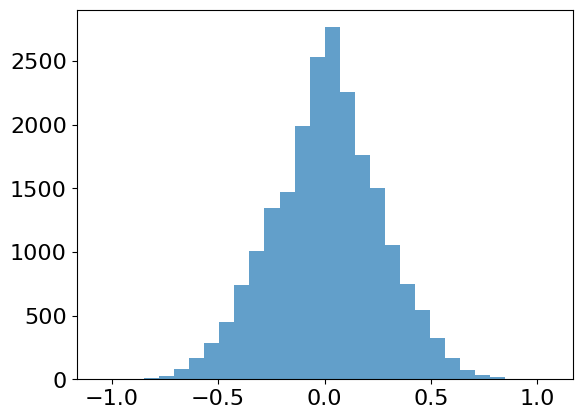

In [9]:
plt.hist(np.log10(dps_df['width_ratio']), bins=30, alpha=0.7, color='C0')
plt.show()

In [10]:
print(len(dps_df[np.log10(dps_df['width_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['width_ratio'])>0]))

10111
11267


In [11]:
dps_df['flux_ratio'] = 0
for i in range(len(dps_df)):
    lam = desi_wavelength/(1+dps_df['Z'][i])
    left_shift = dps_df['DV_L'][i] / c * Halpha_rest[0]
    right_shift = dps_df['DV_R'][i] / c * Halpha_rest[0]

    left_flux = np.max(left_2comp_dps[i][(lam>(Halpha_rest[0]+left_shift-2)) & (lam<(Halpha_rest[0]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(Halpha_rest[0]+right_shift-2)) & (lam<(Halpha_rest[0]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dps_df['Halpha_DP'].iloc[i] is False):
        dps_df['flux_ratio'].iloc[i] = np.nan
    else:
        dps_df['flux_ratio'].iloc[i] = left_flux / right_flux


# dps_df['flux_ratio'] = 0
# for i in range(len(dps_df)):
#     lam = desi_wavelength/(1+dps_df['Z'][i])
#     left_shift = dps_df['DV_L'][i] / c * OIII_rest[1]
#     right_shift = dps_df['dv_r'][i] / c * OIII_rest[1]

#     left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
#     right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

#     if ((right_flux < 1) and (left_flux < 1)) or (dps_df['OIII5007_dp'].iloc[i] is False):
#         dps_df['flux_ratio'].iloc[i] = np.nan
#     else:
#         dps_df['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_30800/1256411409.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dps_df['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel

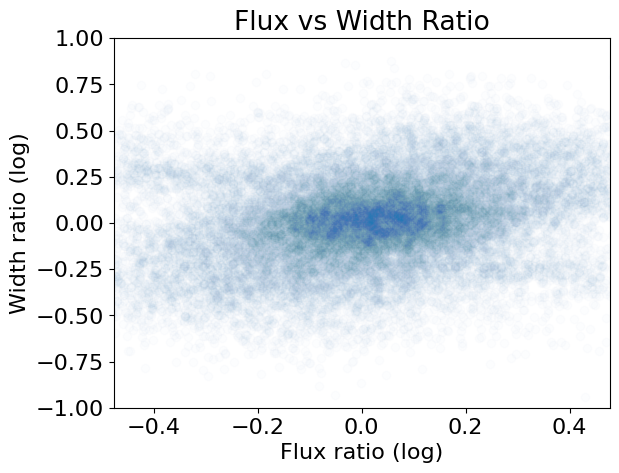

In [12]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(dps_df['width_ratio'])), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(dps_df['width_ratio'])), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.ylim(bottom=np.log10(1/10), top=np.log10(10))
plt.title('Flux vs Width Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/flux_width_ratio.png')
plt.show()

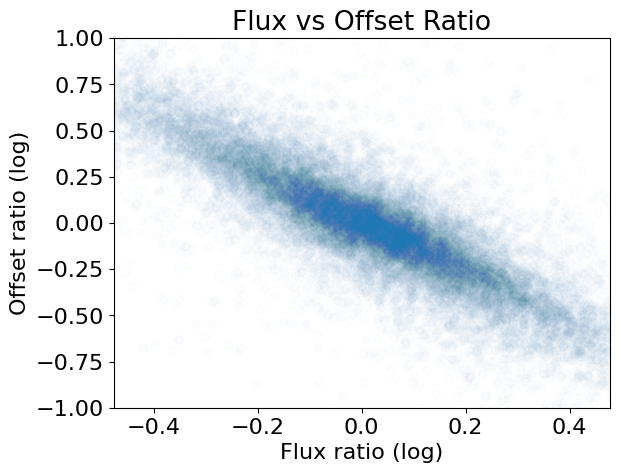

In [13]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(-dps_df['DV_L']/(dps_df['dv_r']))), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.ylim(bottom=-1, top=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.title('Flux vs Offset Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Offset ratio (log)')
plt.savefig('./figures/Feb6/flux_offset_ratio.png')
plt.show()

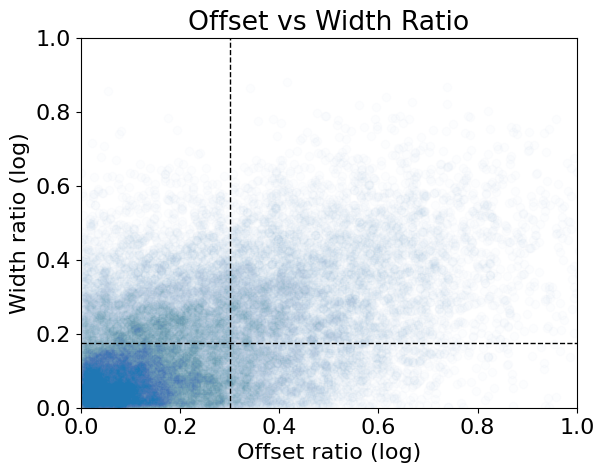

In [14]:
plt.scatter(np.abs(np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
# plt.scatter((np.log10(-dps_df['DV_L']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.axvline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/offset_width_ratio_abs.png')
plt.show()

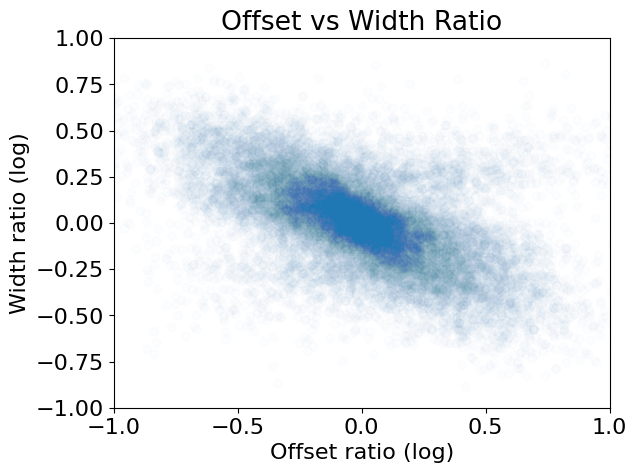

In [15]:
plt.scatter((np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.xlim(left=-1, right=1)
plt.ylim(bottom=-1, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.show()

In [16]:
# print(len(dps_df[np.log10(-dps_df['DV_L']/(dps_df['dv_r']))<0]))
# print(len(dps_df[np.log10(-dps_df['DV_L']/(dps_df['dv_r']))>0]))

In [17]:
def extract_symmetry(df, flux=None, width=None, offset=None):
    combine_crit = np.ones(len(df), dtype=bool)
    
    if flux is True:
        # flux_crit = np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
        combine_crit &= np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
    elif flux is False:
        combine_crit &=  np.abs(np.log10(df['flux_ratio']))>=np.log10(1.3)
    elif flux is None:
        pass

    if width is True:
        combine_crit &= np.abs(np.log10(df['width_ratio']))<np.log10(1.5)
    elif width is False:
        combine_crit &= np.abs(np.log10(df['width_ratio']))>=np.log10(1.5)
    elif width is None:
        pass

    if offset is True:
        combine_crit &= np.abs(np.log10(-df['DV_L']/(df['DV_R'])))<np.log10(2)
    elif offset is False:
        combine_crit &= np.abs(np.log10(-df['DV_L']/(df['DV_R'])))>=np.log10(2)
    elif offset is None:
        pass

    return df[combine_crit]


In [18]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [19]:
dps_df['BPT_class_str'] = dps_df['BPT_2COMP'].map(classification_map)

In [20]:
sWsO = extract_symmetry(dps_df, flux=None, width=True, offset=True)
sWsO.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274887,-78.119110,48.700649,29.866074,...,1,REX,1.000000,1.275339,59.770000,0.000000,131.393997,0.726533,0.975135,unclassified
1,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.890343,-91.399406,57.328384,58.134228,...,2,SER,2.648419,1.265829,124.010002,47.433067,170.289749,1.011130,0.853446,unclassified
2,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.714508,-73.869957,38.259964,50.303444,...,7,SER,1.779606,0.794439,100.040001,50.672260,161.584473,1.190203,1.091793,double SF
3,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,33.346504,-35.933590,38.312683,31.478045,...,9,SER,1.508034,1.499528,62.330002,69.412030,69.280090,0.903872,1.054695,double SF
4,39627739384253866,177.401154,-1.923410,0.322626,10.556721,1.160900,75.357994,-83.433716,62.639977,50.838875,...,2,SER,1.109368,1.686460,200.000000,41.732790,158.791718,0.845142,0.891364,unclassified


In [21]:
print(sWsO['BPT_class_str'].value_counts())

BPT_class_str
double SF       4554
unclassified    2942
SF+COMP          783
double COMP      380
SF+AGN           123
COMP+AGN          89
double AGN        56
COMP+LINER        12
AGN+LINER         12
SF+LINER           2
Name: count, dtype: int64


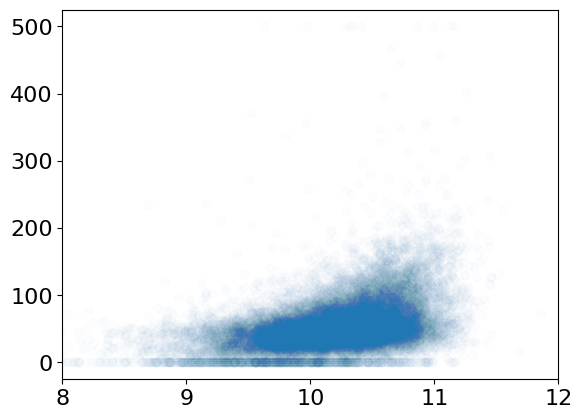

In [22]:
plt.scatter(dps_df['LOGM'], (dps_df['SIGMA_R']), alpha=0.01)
plt.xlim(left=8, right=12)
plt.show()

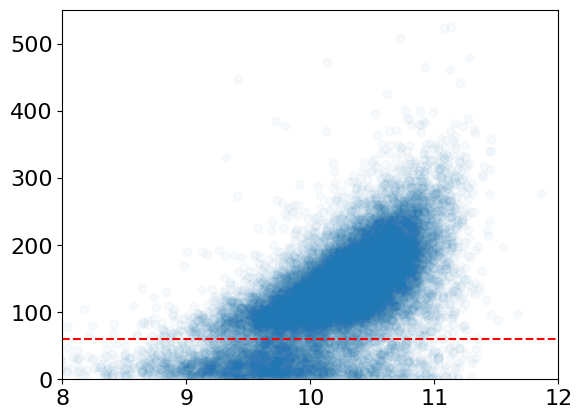

In [23]:
plt.scatter(dps_df['LOGM'], (dps_df['delta_dv']), alpha=0.03)
plt.axhline(60, color='r', linestyle='--')
plt.xlim(left=8, right=12)
plt.ylim(bottom=0)
plt.show()

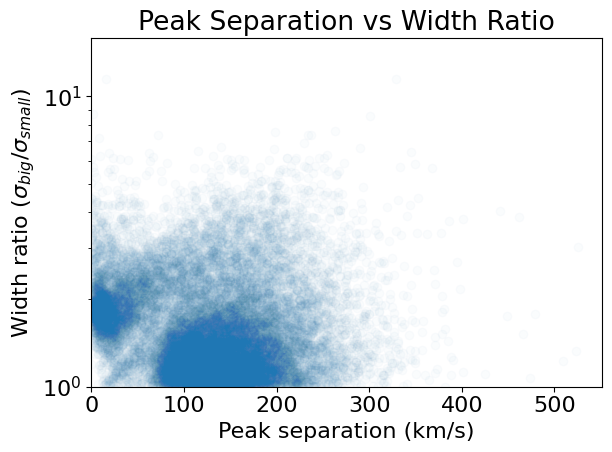

In [24]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
# plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
plt.savefig('./figures/progress_apr/peak_sep_width_ratio.png')
plt.show()

In [25]:

# robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(~dps_df['incl'].isnull())&(dps_df['dp_count']>1)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())&(~robust_dps['flux_ratio'].isnull())]
robust_dps.sort_values(['width_ratio'], ascending=True).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
15931,39627800507843254,220.529312,0.442727,0.179778,10.918049,-10.475061,6.662366e+01,-261.923645,352.986908,0.001002,...,1,SER,6.0,1.156855,186.690002,28.587997,328.547302,0.087393,0.352998,SF+AGN
4747,39627758036322054,209.077072,-1.253912,0.247431,9.521063,1.103340,5.927462e-31,-1.372520,371.748413,31.224941,...,1,REX,1.0,0.370823,376.290009,0.000000,1.372520,0.114805,2.689001,SF+COMP
5478,39627763660882868,184.294128,-0.972807,0.188709,10.269643,-0.257766,1.627626e+02,-74.219650,497.465607,60.542793,...,1,DEV,4.0,0.977100,150.339996,35.666496,236.982254,0.136227,0.996105,SF+AGN
11399,39627782384260041,220.431244,-0.191888,0.394160,11.078855,1.302181,2.796523e+01,-118.579483,164.328201,7.852557,...,1,EXP,1.0,1.593689,144.800003,60.961010,146.544724,0.164397,0.383446,double COMP
14940,39627799958392368,187.911758,0.520320,0.406876,11.231089,-3.629425,1.564640e+01,-137.242401,149.123306,6.381356,...,1,REX,1.0,0.763807,108.430000,0.000000,152.888809,0.176662,0.439223,SF+COMP


In [26]:
print(len(robust_dps))

12427


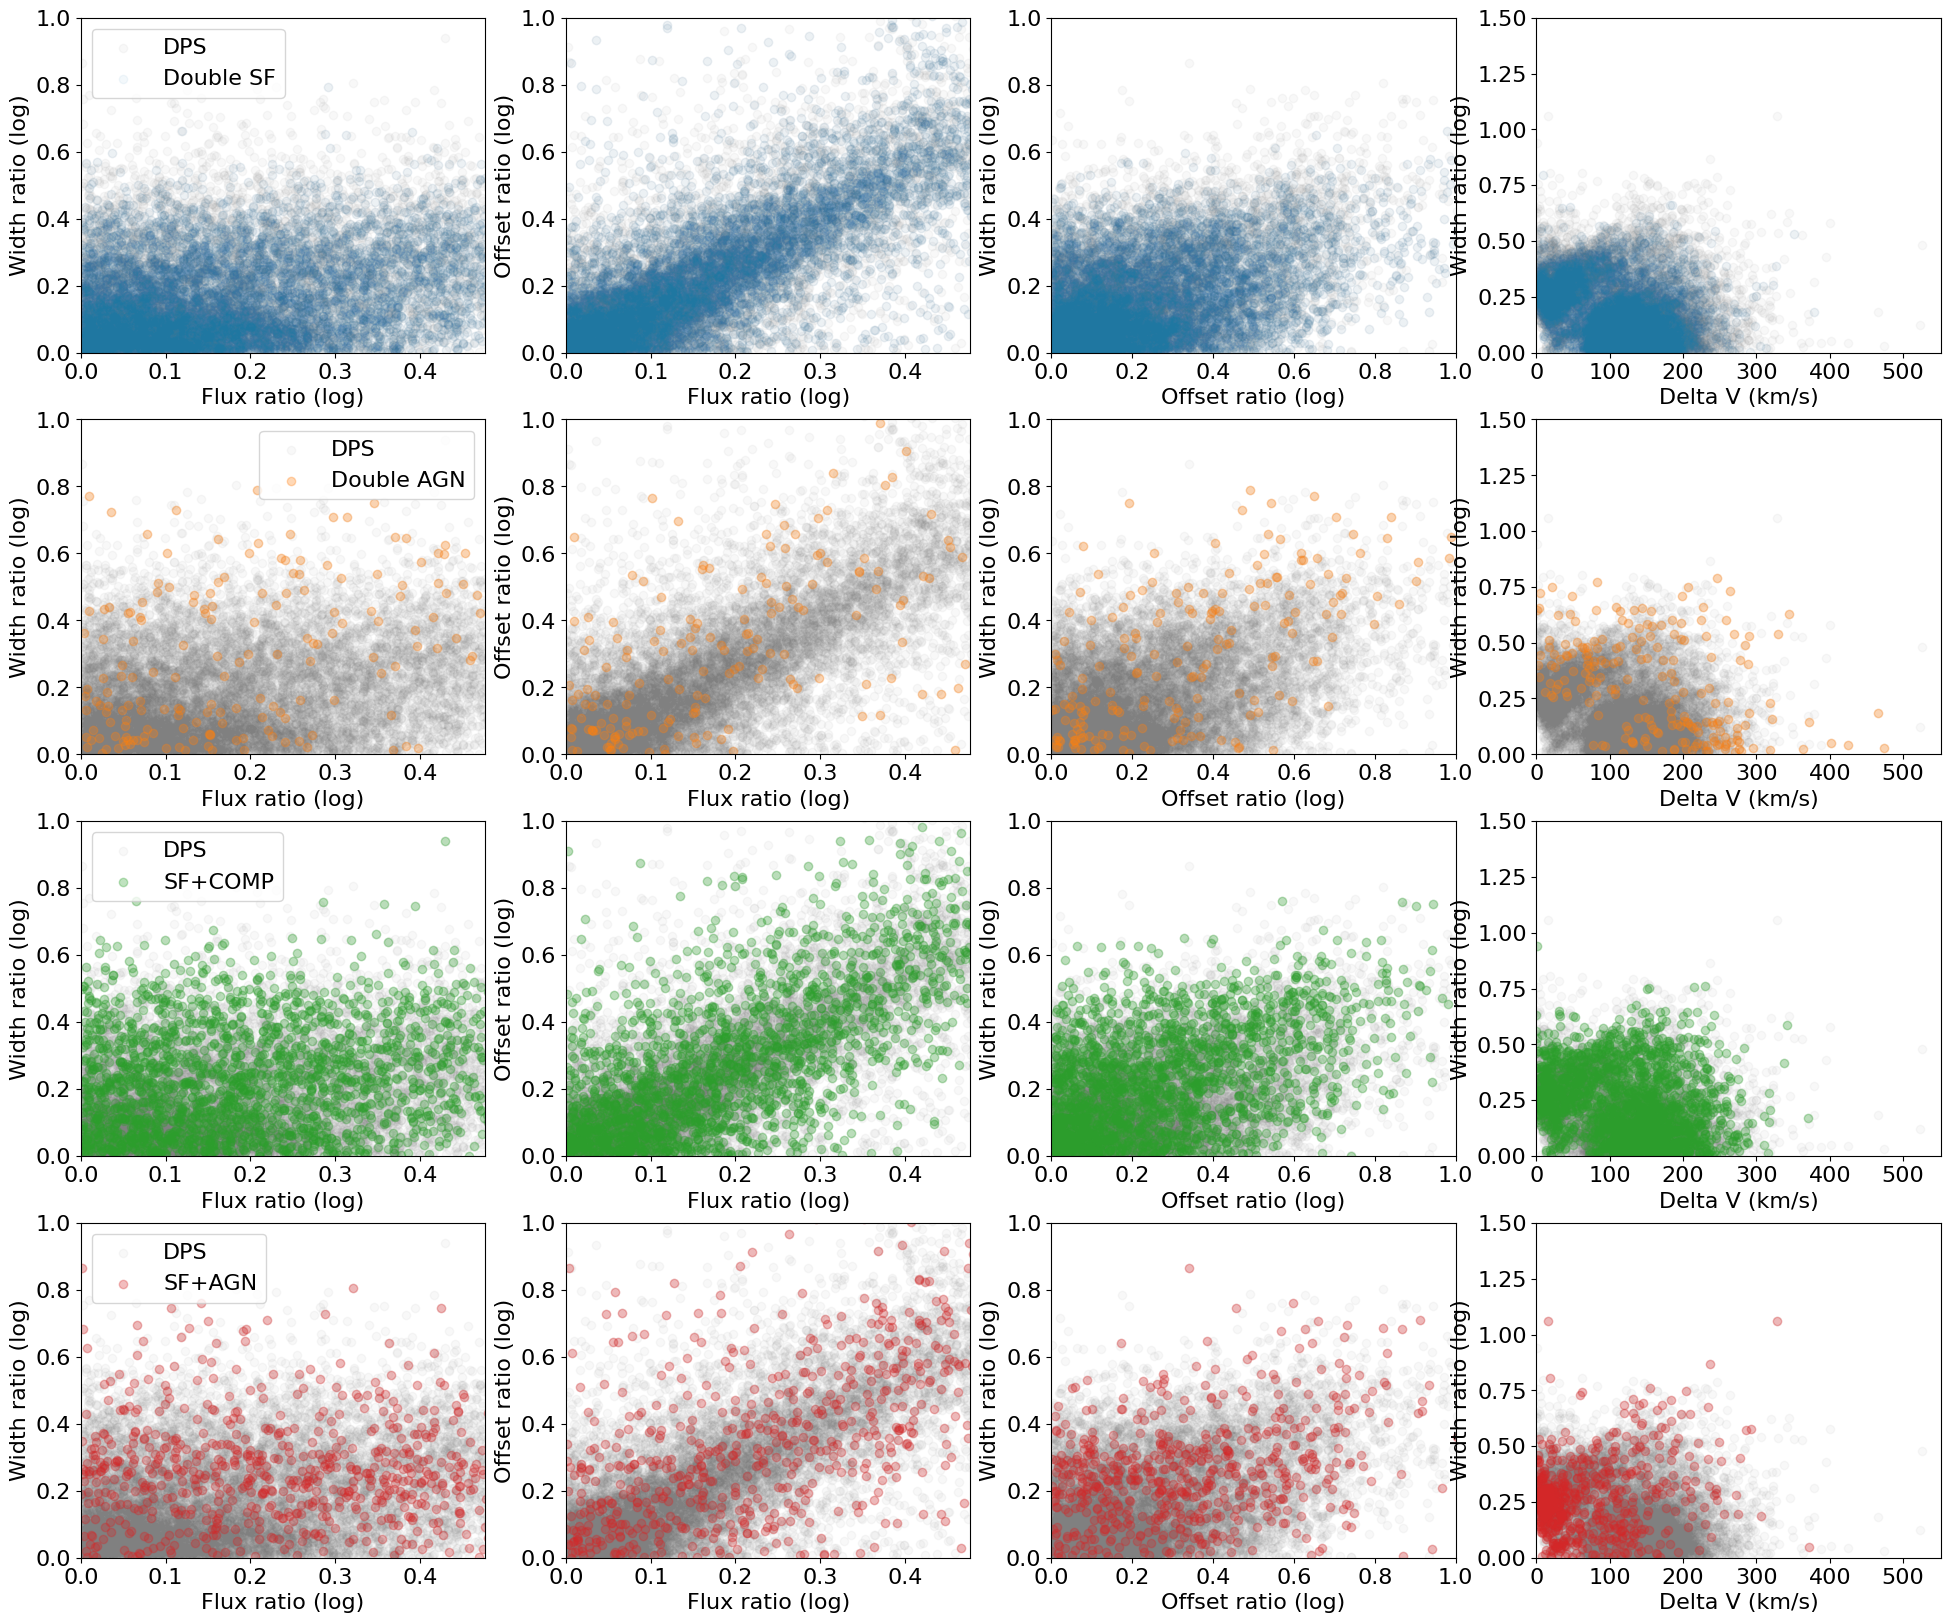

In [33]:

dSF = robust_dps[robust_dps['BPT_class_str']=='double SF'].copy()
dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN'].copy()
SF_COMP = robust_dps[robust_dps['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = robust_dps[robust_dps['BPT_class_str']=='SF+AGN'].copy()

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

labels = ['Double SF', 'Double AGN', 'SF+COMP', 'SF+AGN']
colors = ['C0', 'C1', 'C2', 'C3']
for i, subset in enumerate([dSF, dAGN, SF_COMP, SF_AGN]):
    ax = axes[i]
    ax[0].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(robust_dps['width_ratio'])), alpha=.05, color='gray', label='DPS')
    ax[0].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(subset['width_ratio'])), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[0].set_xlim(left=0, right=np.log10(3))
    ax[0].set_ylim(bottom=0, top=np.log10(10))
    ax[0].set_xlabel('Flux ratio (log)')
    ax[0].set_ylabel('Width ratio (log)')
    ax[0].legend()


    ax[1].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(-robust_dps['DV_L']/(robust_dps['DV_R']))), alpha=.05, color='gray', label='DPS')
    ax[1].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(-subset['DV_L']/(subset['DV_R']))), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[1].set_ylim(bottom=0, top=1)
    ax[1].set_xlim(left=0, right=np.log10(3))
    ax[1].set_xlabel('Flux ratio (log)')
    ax[1].set_ylabel('Offset ratio (log)')

    ax[2].scatter(np.abs(np.log10(-robust_dps['DV_L']/(robust_dps['DV_R']))), np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[2].scatter(np.abs(np.log10(-subset['DV_L']/(subset['DV_R']))), np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[2].set_xlim(left=0, right=1)
    ax[2].set_ylim(bottom=0, top=1)
    ax[2].set_xlabel('Offset ratio (log)')
    ax[2].set_ylabel('Width ratio (log)')
    
    ax[3].scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[3].scatter(subset['delta_dv'], np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[3].set_xlim(left=0)
    ax[3].set_ylim(bottom=0, top=1.5)
    ax[3].set_xlabel('Delta V (km/s)')
    ax[3].set_ylabel('Width ratio (log)')


plt.show()




In [34]:
# merger_cand = robust_dps[((robust_dps['width_ratio']<1/3)|(robust_dps['width_ratio']>3))].copy()
# merger_cand_b = merger_cand[(merger_cand['width_ratio']>3)&(merger_cand['sigma_l']<250)&(merger_cand['sigma_r']>1)].copy()
# merger_cand_r = merger_cand[(merger_cand['width_ratio']<1/3)&(merger_cand['sigma_r']<250)&(merger_cand['sigma_l']>1)].copy()
# merger_cand = pd.concat([merger_cand_b, merger_cand_r])
# merger_cand.sort_values(['width_ratio'], ascending=False).head(5)

In [35]:
# for i, id in enumerate(merger_cand.sort_values(['width_ratio'], ascending=False).head(10)['TARGETID'].to_list()):
#     df = merger_cand[merger_cand['TARGETID'] == id]
#     print(df['BPT_class_str'])
#     print(image_link(df['RA'].iloc[0], df['DEC'].iloc[0], plot=True, save_image=True, fname=f"./images/{id}_image.jpg"))

In [36]:
# plt.scatter(robust_dps['LOGM'], np.log10(robust_dps['sigma_l']/robust_dps['VD_SL']), alpha=0.05)
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.xlim(left=8, right=12)
# plt.show()

In [37]:
# from scipy.stats import binned_statistic

# # Bin the data by 'LOGM'
# bin_means, bin_edges, binnumber = binned_statistic(robust_dps['LOGM'],
#                                                    robust_dps['sigma_l'] - robust_dps['VD_SL'],
#                                                    statistic='mean',
#                                                    bins=5, range=(9, 11.5))
# bin_stds, _, _ = binned_statistic(robust_dps['LOGM'],
#                                   robust_dps['sigma_l'] - robust_dps['VD_SL'],
#                                   statistic='std',
#                                   bins=5, range=(9, 11.5))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# # Create the plot
# # plt.figure(figsize=(8, 6))
# # Plot the original scatter data
# plt.scatter(robust_dps['LOGM'], robust_dps['sigma_l'] - robust_dps['VD_SL'], alpha=0.05, label='All data')
# # Plot the binned means with error bars
# plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='r', label='Binned Mean +/- Std Dev')

# # Set plot labels and limits
# plt.xlabel('LOGM')
# plt.ylabel('sigma_l - VD_SL')
# plt.xlim(left=8, right=12)
# plt.legend()
# plt.show()

In [38]:
robust_dps.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [39]:
# plt.scatter(robust_dps['Z'], robust_dps['LOGM'], alpha=0.05)
# plt.show()

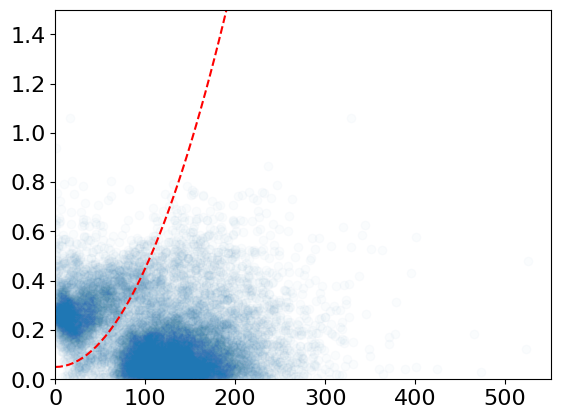

In [40]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.02)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

In [41]:
cake_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 < np.abs(np.log10(robust_dps['width_ratio']))].copy()
horn_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 > np.abs(np.log10(robust_dps['width_ratio']))].copy()

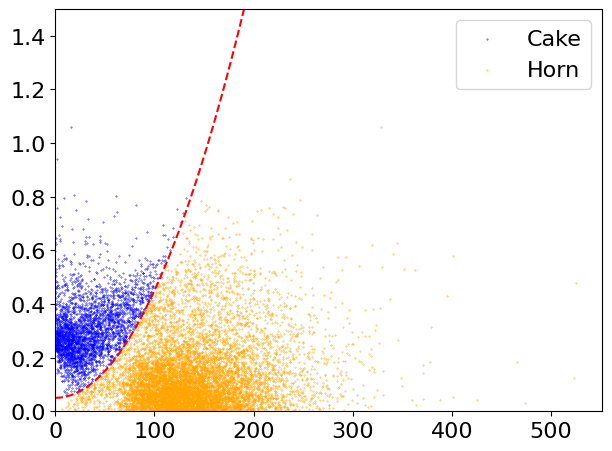

In [42]:
plt.scatter(cake_dps['delta_dv'], np.abs(np.log10(cake_dps['width_ratio'])), alpha=1, color='blue', label='Cake', s=0.1)
plt.scatter(horn_dps['delta_dv'], np.abs(np.log10(horn_dps['width_ratio'])), alpha=1, color='orange', label='Horn', s=0.1)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn.png')
plt.show()

In [43]:
cake_dps.sort_values('delta_dv').head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
1430,39627745780568021,198.692856,-1.726080,0.177899,9.397820,0.343936,5.529180e-35,-1.108048e-36,65.855171,12.411544,...,1,SER,0.706492,1.619631,152.130005,44.214924,5.639985e-35,0.458935,1.546016,double SF
444,39627739828849998,203.917831,-1.950469,0.175892,10.072911,0.922826,7.515309e-36,-2.395522e-34,92.165497,30.695520,...,4,SER,1.222276,2.592370,65.599998,60.862194,2.470675e-34,0.449050,1.358830,double SF
3335,39627752072024556,213.710022,-1.389540,0.121892,9.376883,0.108368,1.271377e-22,-2.582509e-25,73.982635,21.526140,...,2,SER,2.461597,0.791459,64.220001,51.118576,1.273959e-22,0.482930,2.801607,double SF
1494,39627745809925559,200.318481,-1.840596,0.136506,10.679117,-0.137904,2.168690e-24,-6.706307e-18,141.554794,17.910248,...,1,SER,1.461649,2.679517,124.980003,73.566680,6.706309e-18,0.253507,0.822366,COMP+AGN
15202,39627800126161840,197.792908,0.439395,0.082694,10.614749,0.304508,3.160755e-16,-3.933333e-23,213.113129,66.423141,...,1,SER,4.362458,6.858890,95.449997,56.831028,3.160755e-16,0.345292,5.951549,COMP+LINER
2174,39627746183221164,222.653030,-1.650818,0.205599,9.707138,0.831951,1.837843e-15,-1.648361e-19,71.213928,10.538811,...,1,REX,1.000000,1.228479,41.040001,0.000000,1.838008e-15,0.414558,2.773250,double SF
8463,39627775669178163,180.150146,-0.526897,0.082889,11.009003,0.416685,6.131923e-14,-2.554961e-16,38.540329,144.001587,...,2,SER,1.167298,4.558913,181.429993,68.579760,6.157473e-14,2.887505,1.807891,SF+COMP
19201,39627817947760982,180.126999,1.311985,0.095644,10.511074,-7.431584,1.239548e-12,-1.013242e-11,131.676727,25.952427,...,2,SER,2.267525,1.902847,161.839996,77.080370,1.137196e-11,0.311074,0.994515,SF+COMP
16823,39627806228874607,201.571243,0.633192,0.111247,9.859956,0.880214,1.987721e-19,-1.881048e-11,116.195732,29.183527,...,5,SER,2.006629,1.448685,144.470001,46.852016,1.881048e-11,0.364043,0.627042,double SF
3226,39627751996523594,209.052490,-1.394487,0.199087,10.746824,1.398813,4.519228e-14,-2.292754e-11,166.302963,46.606453,...,2,SER,0.758203,2.854361,139.830002,74.049515,2.297273e-11,0.329341,0.433285,COMP+AGN


In [44]:
horn_dps.sort_values('delta_dv', ascending=False).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
2342,39627751522568102,180.848053,-1.412246,0.316521,11.136950,1.728777,25.056154,-500.000000,163.540970,500.000000,...,1,DEV,4.000000,2.239528,133.000000,51.958690,525.056152,3.018890,0.341627,COMP+AGN
21112,39627824432153845,206.548203,1.463832,0.381111,11.075592,0.141859,483.604309,-39.861435,273.621094,205.468109,...,1,EXP,1.000000,0.997921,200.000000,64.654915,523.465759,0.753606,2.575983,COMP+LINER
16868,39627806241460155,202.443680,0.645763,0.260044,10.133579,1.316232,222.211166,-251.234451,151.977737,163.025116,...,6,DEV,4.000000,0.600868,92.029999,60.984920,473.445618,1.070222,0.874548,double AGN
5854,39627763858017970,196.185196,-0.906858,0.306150,10.920185,1.325015,119.281151,-346.596619,268.102142,174.780945,...,1,SER,2.010492,1.394982,152.850006,48.985540,465.877777,0.656651,0.235147,double AGN
16445,39627806014964884,188.788483,0.759762,0.233901,10.619380,1.104108,238.799988,-185.993195,157.046387,141.843597,...,6,SER,3.290994,0.977520,177.429993,43.231460,424.793182,0.906690,1.136725,double AGN
405,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,203.714050,-197.337509,168.523346,149.044693,...,5,SER,6.000000,1.987401,205.649994,60.036884,401.051575,0.888425,1.131369,double AGN
9601,39627776231214141,213.629364,-0.511932,0.137945,10.881363,1.399993,234.694244,-166.120255,72.462852,298.555695,...,3,SER,4.291133,3.566140,309.049988,46.921177,400.814514,3.788663,1.828196,double COMP
7688,39627770032033200,204.140244,-0.660093,0.415810,10.521138,1.863829,65.620667,-329.584351,184.459030,500.000000,...,1,PSF,0.000000,0.000000,175.339996,0.000000,395.205017,2.688061,0.769457,double COMP
11102,39627782229070929,211.244568,-0.227199,0.239755,10.791212,0.228841,141.589081,-246.857391,129.763153,143.274704,...,3,SER,2.228509,2.343354,200.070007,40.051037,388.446472,1.099248,0.459736,COMP+AGN
7296,39627769847485338,193.232574,-0.829209,0.170288,10.891941,0.339846,264.280670,-114.398788,77.919807,170.035629,...,2,DEV,4.000000,2.532884,226.210007,46.740032,378.679443,2.059517,0.928276,double COMP


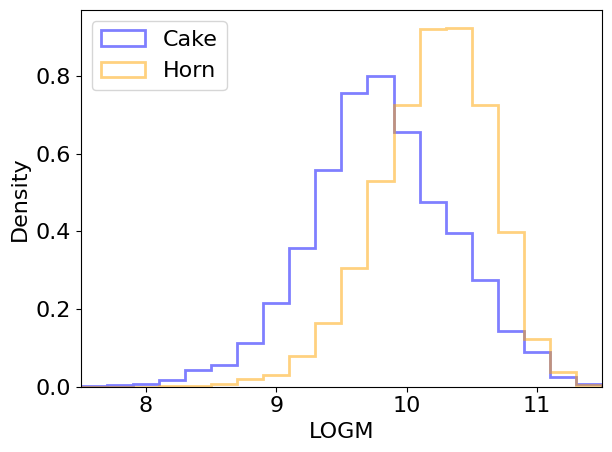

In [45]:
plt.hist(cake_dps['LOGM'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(7.5, 11.5))
plt.hist(horn_dps['LOGM'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(7.5, 11.5))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=7.5, right=11.5)
# plt.savefig('./figures/Feb25/cake_horn_logm.png')
plt.show()

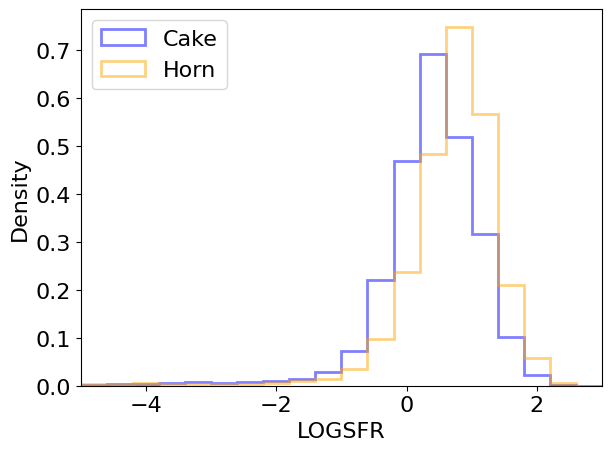

In [46]:
plt.hist(cake_dps['LOGSFR'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(-5, 3))
plt.hist(horn_dps['LOGSFR'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(-5, 3))
plt.xlabel('LOGSFR')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=-5, right=3)
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn_logsfr.png')
plt.show()

In [47]:
print(cake_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(cake_dps))

BPT_class_str
double SF         60.025873
SF+COMP           19.307891
SF+AGN            11.739974
COMP+AGN           2.943079
double COMP        2.263907
double AGN         1.843467
SF+LINER           0.582147
AGN+LINER          0.452781
COMP+LINER         0.420440
AGN+uncertain      0.226391
COMP+uncertain     0.194049
Name: proportion, dtype: float64
3092


In [48]:
print(horn_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(horn_dps))

BPT_class_str
double SF         68.216390
SF+COMP           16.689877
double COMP        7.177290
SF+AGN             3.085163
COMP+AGN           2.313873
double AGN         1.521157
COMP+LINER         0.417783
AGN+LINER          0.332084
SF+LINER           0.203535
COMP+uncertain     0.032137
AGN+uncertain      0.010712
Name: proportion, dtype: float64
9335


In [49]:
# plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.02)
# # x = np.linspace(8, 11.5, 100)
# # y = 55*(x-9)+55
# # plt.plot(x, y, color='black', lw=2)
# plt.show()

In [50]:
# len(merger_cand)

In [51]:
# merger_cand.sort_values(by='SHAPE_R', ascending=True).head(30)

In [52]:
# print(merger_cand['MORPHTYPE'].value_counts(normalize=True))

In [53]:
# merger_cand.sort_values(by='SERSIC', ascending=True).head(20)

In [54]:
# fig, ax = plt.subplots(figsize=(9, 6))

# # Data to plot
# datasets = [robust_dps, dSF, SF_AGN, SF_COMP, dAGN]
# labels = ['DPS', 'Double SF', 'SF+AGN', 'SF+COMP', 'Double AGN']
# colors = ['k', 'blue', 'green', 'purple', 'red']

# # Calculate means and quantiles for SERSIC index
# means = [df['SERSIC'].mean() for df in datasets]
# q25 = [df['SERSIC'].quantile(0.2) for df in datasets]
# q75 = [df['SERSIC'].quantile(0.8) for df in datasets]

# # Calculate asymmetric errors
# errors = [np.array([means[i] - q25[i], q75[i] - means[i]]).reshape(2, 1) for i in range(len(datasets))]

# # Create the error bar plot
# for i, df in enumerate(datasets):
#     ax.errorbar(labels[i], means[i], yerr=errors[i], fmt='o', capsize=5, color=colors[i], ecolor=colors[i], elinewidth=2)

# # Add some jittered scatter points for visualization
# # for i, df in enumerate(datasets):
# #     # Generate jitter for x-axis
# #     jitter = np.random.normal(0, 0.05, size=len(df))
# #     ax.scatter([i + j for j in jitter], df['SERSIC'], alpha=0.01, color=colors[i])
# ax.axhline(means[0], color='gray', linestyle='--', linewidth=1)
# ax.set_xticklabels(labels=labels, fontsize=12)
# ax.set_ylabel('SERSIC Index', fontsize=12)
# # ax.set_title('SERSIC Index Distribution by BPT Class', fontsize=14)
# ax.set_ylim(bottom=0, top=6.1)
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/SERSIC_by_BPT_class.png')
# plt.show()

In [55]:
# robust_dps[robust_dps['SERSIC']>4].head(20)

In [56]:
# plt.hist(robust_dps['SERSIC'], align='mid', bins=12)
# plt.show()

In [57]:
# dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN']
# print(len(dAGN))
# for i in range(len(dAGN)):
#     ra, dec = dAGN.iloc[i][['RA', 'DEC']]
#     r = dAGN.iloc[i]['SHAPE_R']
#     if r < 1:
#         image_link(ra, dec, side_arcmin=0.3, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")
#     else:
#         image_link(ra, dec, side_arcmin=0.5/3*r, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")

In [58]:
# # plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
# plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3)
# plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3)
# plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3)
# plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3)
# plt.xlim((0, 0.45))
# plt.xlabel('Z')
# plt.ylabel('Density')
# plt.legend()
# plt.title('Distribution of redshift for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/redshift_distribution.png')
# plt.show()

In [59]:
# # plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=False, linewidth=3)
# plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
# plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
# plt.xlim((0, 0.45))
# plt.ylim((0, 1))
# plt.xlabel('Z')
# plt.ylabel('Cumulative Fraction')
# plt.legend()
# plt.title('Cumulative Fraction of redshift for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/redshift_cumulative_distribution.png')
# plt.show()

In [60]:
# # plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
# plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3)
# plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3)
# plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3)
# plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3)
# plt.xlim((8, 12))
# plt.xlabel('LOGM')
# plt.ylabel('Density')
# plt.legend()
# plt.title('Distribution of LOGM for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/logm_distribution.png')
# plt.show()

In [61]:
# # plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
# plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
# plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3, cumulative=True)
# plt.xlim((8, 12))
# plt.ylim((0, 1))
# plt.xlabel('LOGM')
# plt.ylabel('Cumulative Fraction')
# plt.title('Cumulative Distribution of LOGM for Different BPT Classes')
# plt.legend()
# # plt.savefig('./figures/Feb25/logm_cumulative_distribution.png')
# plt.show()

In [62]:
# plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3)
# plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3)
# plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3)
# plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3)
# plt.xlim((-6, 2))
# plt.xlabel('log(SFR)')
# plt.ylabel('Density')
# plt.title('Distribution of LOGSFR for Different BPT Classes')
# plt.legend()
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/logsfr_distribution.png')
# plt.show()

In [63]:
# plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
# plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3, cumulative=True)
# plt.xlim((-6, 2))
# plt.ylim((0, 1))
# plt.xlabel('log(SFR)')
# plt.ylabel('Cumulative Density')
# plt.legend()
# plt.title('Cumulative Distribution of LOGSFR for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/logsfr_cumulative_distribution.png')
# plt.show()

In [64]:
# plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3)
# plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3)
# plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3)
# plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3)
# plt.xlim((-15, -7))
# plt.xlabel('log(sSFR)')
# plt.ylabel('Density')
# plt.legend()
# plt.title('Distribution of log(sSFR) for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/logssfr_distribution.png')
# plt.show()

In [65]:
# plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3, cumulative=True)
# plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3, cumulative=True)
# plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3, cumulative=True)
# plt.xlim((-15, -7))
# plt.ylim((0, 1))
# plt.xlabel('log(sSFR)')
# plt.ylabel('Cumulative Fraction')
# plt.legend()
# plt.title('Cumulative Distribution of log(sSFR) for Different BPT Classes')
# plt.tight_layout()
# # plt.savefig('./figures/Feb25/logssfr_cumulative_distribution.png')
# plt.show()

In [66]:
# Mr_Ml_ratio = np.log10(-dAGN['DV_L']/dAGN['dv_r'])
# plt.scatter((np.log10(-dps_df['DV_L']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01, color='gray')
# plt.scatter((Mr_Ml_ratio), (np.log10(dAGN['width_ratio'])), alpha=0.5)
# plt.xlim((-1.5, 1.5))
# plt.ylim((-1, 1))
# plt.show()